# YAP476 Data Mining Project
## Instacart Multilevel Mining
**Topic 5: Multi-Level & Multi-Dim. Mining**
*Book: Han, J.W., Kamber, M. and Pei, J. (2012) Data Mining Concepts and Techniques. 3rd Edition, Morgan Kaufmann Publishers, Waltham.*

In [ ]:
# imports & setup
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
from IPython.display import display

plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

def get_memory_usage(df): return df.memory_usage(deep=True).sum() / 1024**2

In [ ]:
### Loading the datasets, casting appropriate data types for memory optimization, and merging
products = pd.read_csv('products.csv')
aisles = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')
order_products = pd.read_csv('order_products__prior.csv', nrows = 2e6)

aisles['aisle'] = aisles['aisle'].astype('category')
departments['department'] = departments['department'].astype('category')
products['product_name'] = products['product_name'].astype('category')

df_merged = order_products.merge(products, on='product_id', how='left')
df_merged = df_merged.merge(aisles, on='aisle_id', how='left')
df_merged = df_merged.merge(departments, on='department_id', how='left')

orders = pd.read_csv('orders.csv')[['order_id', 'order_dow', 'order_hour_of_day']]
df_merged = df_merged.merge(orders, on='order_id', how='left')

for col in ['order_dow', 'order_hour_of_day']: df_merged[col] = df_merged[col].astype('int8')

print("shape:", df_merged.shape)
print("\nattributes:", df_merged.columns.tolist())
print("\nbasic stats for numeric columns:")
display(df_merged.describe())

def opt(df):
    for col in df.columns:
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
        elif df[col].dtype == 'float64': df[col] = df[col].astype('float32')
    return df

df_merged = opt(df_merged)

shape: (2000000, 11)

attributes: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'order_dow', 'order_hour_of_day']

basic stats for numeric columns:


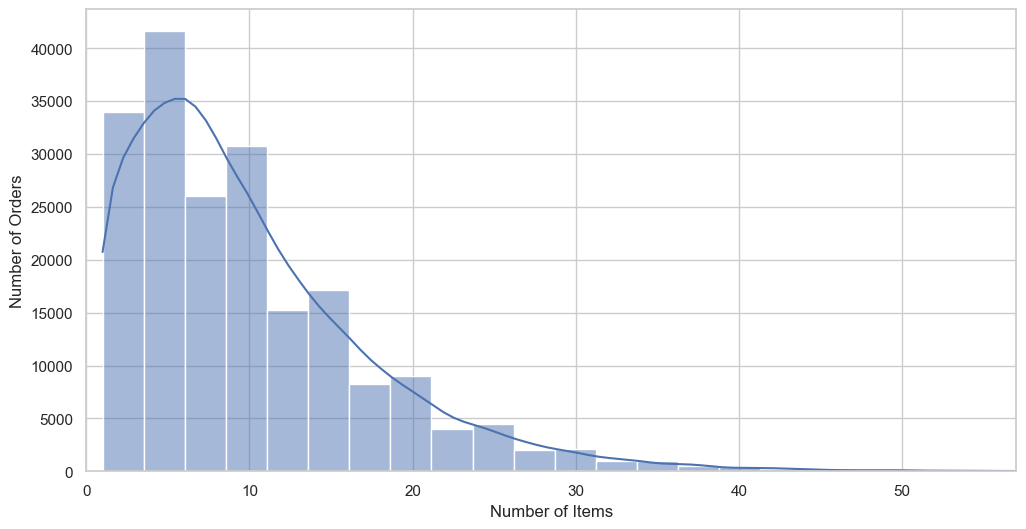

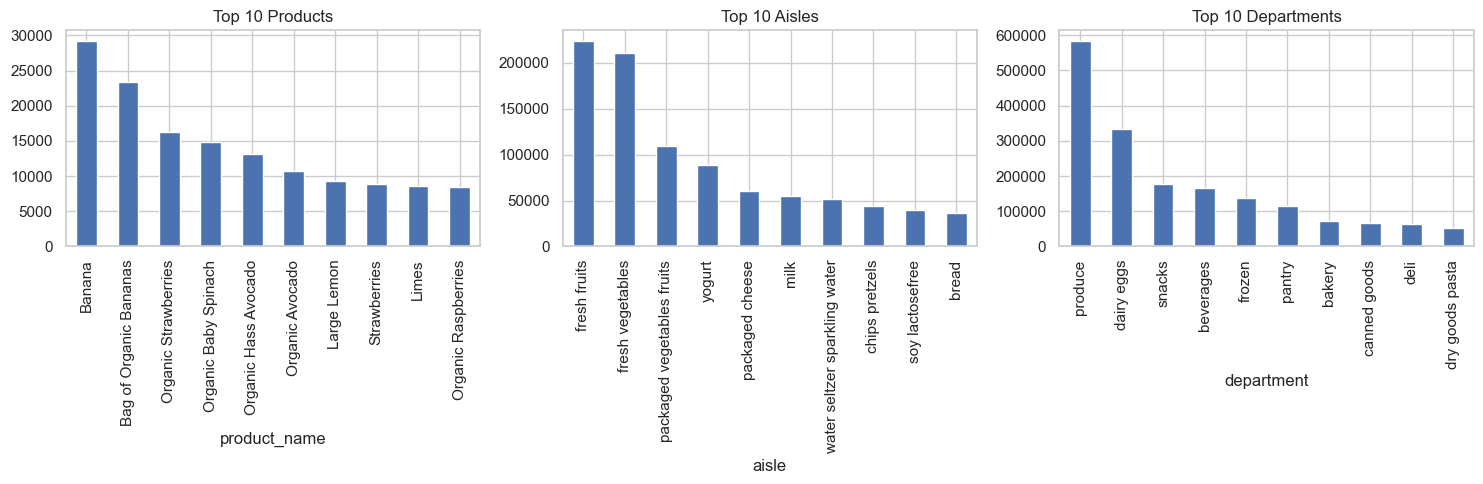

In [3]:
#prepping 'understanding data' section in report
plt.figure(figsize=(12, 6))
basket_size = df_merged.groupby('order_id').size()
sns.histplot(
    basket_size,
    bins=50,
    kde=True,
    #color=''
)
plt.xlabel('Number of Items')
plt.ylabel('Number of Orders')
plt.xlim(0, 57)
plt.show()

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
df_merged['product_name'].value_counts()[:10].plot(kind='bar', title='Top 10 Products')
plt.subplot(1, 3, 2)
df_merged['aisle'].value_counts()[:10].plot(kind='bar', title='Top 10 Aisles')
plt.subplot(1, 3, 3)
df_merged['department'].value_counts()[:10].plot(kind='bar', title='Top 10 Departments')
plt.tight_layout()
plt.show()


--- Processing: Level: department, Dimension: Weekend ---
Sup: 0.05 | Algo: fpgrowth | Time: 1.46s | Rules: 3574
Sup: 0.05 | Algo: apriori | Time: 0.55s | Rules: 3574
Sup: 0.02 | Algo: fpgrowth | Time: 1.57s | Rules: 28462
Sup: 0.02 | Algo: apriori | Time: 0.86s | Rules: 28462
Sup: 0.01 | Algo: fpgrowth | Time: 0.88s | Rules: 110108
Sup: 0.01 | Algo: apriori | Time: 1.69s | Rules: 110108

--- Processing: Level: aisle, Dimension: Weekend ---
Sup: 0.05 | Algo: fpgrowth | Time: 2.31s | Rules: 606
Sup: 0.05 | Algo: apriori | Time: 0.47s | Rules: 606
Sup: 0.02 | Algo: fpgrowth | Time: 4.33s | Rules: 5564
Sup: 0.02 | Algo: apriori | Time: 3.37s | Rules: 5564
Sup: 0.01 | Algo: fpgrowth | Time: 6.45s | Rules: 30458
Sup: 0.01 | Algo: apriori | Time: 25.30s | Rules: 30458

--- Processing: Level: product_name, Dimension: Weekend ---
Sup: 0.05 | Algo: fpgrowth | Time: 5.57s | Rules: 0
Sup: 0.05 | Algo: apriori | Time: 1.33s | Rules: 0
Sup: 0.02 | Algo: fpgrowth | Time: 6.09s | Rules: 8
Sup: 0.02 

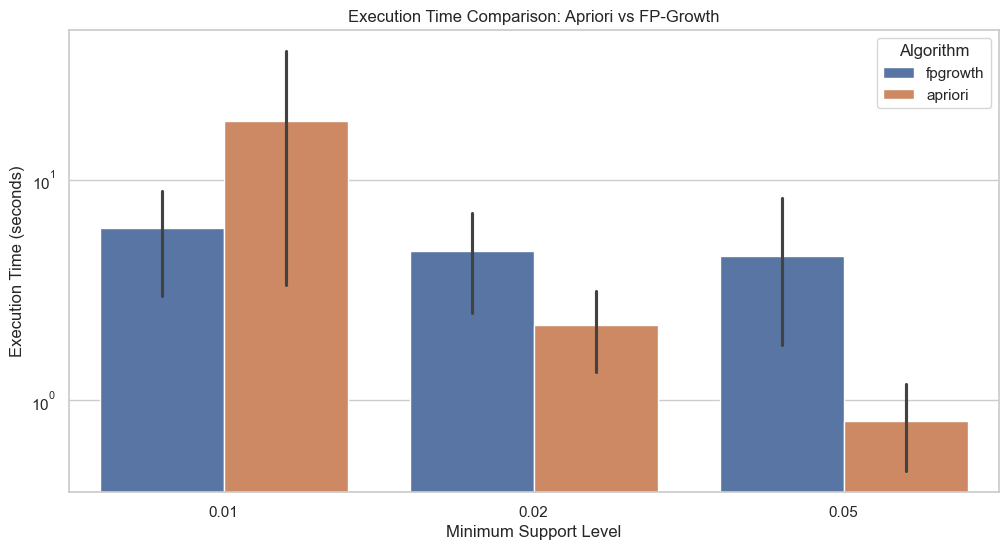

In [ ]:
# feature eng
def prepare_multidimensional_data(df):
    bins = [0, 6, 12, 18, 24]
    labels = ['Night', 'Morning', 'Afternoon', 'Evening']
    df['hour_bin'] = pd.cut(df['order_hour_of_day'], bins=bins, labels=labels, right=False)
    df['hour_bin'] = 'Hour_' + df['hour_bin'].astype(str)
    df['day_type'] = df['order_dow'].apply(lambda x: 'Weekend' if x in [0, 1] else 'Weekday')
    basket_counts = df.groupby('order_id')['product_id'].transform('count')
    df['basket_size'] = pd.cut(basket_counts, bins=[0, 5, 15, 100], labels=['Small_Basket', 'Medium_Basket', 'Large_Basket'])
    return df

df_merged = prepare_multidimensional_data(df_merged)
display(df_merged.head())


### Transaction Encoding
def get_basket(df, level_column, is_sparse=True):
    df = df.dropna(subset=[level_column, 'hour_bin', 'day_type', 'basket_size'])
    baskets = df.groupby('order_id')[level_column].unique().reset_index()
    meta = df.drop_duplicates('order_id')[['order_id', 'hour_bin', 'day_type', 'basket_size']]
    merged = baskets.merge(meta, on='order_id')
    items_list = merged[level_column].tolist()
    meta_cols = ['hour_bin', 'day_type', 'basket_size']
    meta_list = merged[meta_cols].fillna('Unknown').astype(str).values.tolist()
    transaction_list = [list(items) + meta for items, meta in zip(items_list, meta_list)]
    te = TransactionEncoder()
    te_ary = te.fit(transaction_list).transform(transaction_list, sparse=is_sparse)
    return pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_) if is_sparse else pd.DataFrame(te_ary, columns=te.columns_)

### Algorithm & Dimension Comparison
def run_mining_experiment(levels=['department', 'aisle', 'product_name'], supports=[0.05, 0.02, 0.01], algos=['fpgrowth', 'apriori']):
    results = []
    all_rules = {}
    dimensions = {
        'Weekend': df_merged[df_merged['order_dow'].isin([0, 1])],
        'Weekday': df_merged[~df_merged['order_dow'].isin([0, 1])]
    }
    
    for dim_name, dim_df in dimensions.items():
        for level in levels:
            print(f"\n--- Processing: Level: {level}, Dimension: {dim_name} ---")
            dim_basket = get_basket(dim_df, level, is_sparse=(level == 'product_name'))
            
            for min_sup in supports:
                for algo_name in algos:
                    try:
                        start_time = time.time()
                        if algo_name == 'apriori': frequent_itemsets = apriori(dim_basket, min_support=min_sup, use_colnames=True)
                        else: frequent_itemsets = fpgrowth(dim_basket, min_support=min_sup, use_colnames=True)
                        exec_time = time.time() - start_time
                        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
                        
                        if not rules.empty:
                            rules['kulczynski'] = ((rules['support']/rules['antecedent support']) + (rules['support']/rules['consequent support'])) / 2
                            rules['ir'] = np.abs(rules['antecedent support'] - rules['consequent support']) / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
                            robust_count = len(rules[(rules['kulczynski'] > 0.5) & (rules['ir'] < 0.3)])
                        else: robust_count = 0
                            
                        results.append({
                            'Dimension': dim_name,
                            'Level': level,
                            'Min_Support': min_sup,
                            'Algorithm': algo_name,
                            'Exec_Time': exec_time,
                            'Total_Rules': len(rules),
                            'Robust_Rules': robust_count
                        })
                        all_rules[(dim_name, level, min_sup)] = rules
                        print(f"Sup: {min_sup} | Algo: {algo_name} | Time: {exec_time:.2f}s | Rules: {len(rules)}")
                    except Exception as e: 
                        print(f"err: ({algo_name} - {level}): {e}")
    return pd.DataFrame(results), all_rules

benchmark_df, all_rules = run_mining_experiment()

plt.figure(figsize=(12, 6))
sns.barplot(data=benchmark_df, x='Min_Support', y='Exec_Time', hue='Algorithm')
plt.title('Execution Time Comparison: Apriori vs FP-Growth')
plt.xlabel('Minimum Support Level')
plt.ylabel('Execution Time (seconds)')
plt.yscale('log')
plt.show()

In [ ]:
def display_robust_rules(rules_df, level_name, top_n=10):
    if rules_df.empty: return
    robust = rules_df[(rules_df['kulczynski'] > 0.2) & (rules_df['ir'] < 0.6)]
    display(robust.sort_values('kulczynski', ascending=False).head(top_n))

sample_key = ('Weekend', 'product_name', 0.01)
if sample_key in all_rules:
    display_robust_rules(all_rules[sample_key], "Ürün Seviyesi (Hafta Sonu)")

In [ ]:
# helpers

def plot_rules_network(rules_df, title="Association Rules Network", num_rules=30):
    if rules_df.empty:
        print(f"No rules to plot for: {title}")
        return

    G = nx.DiGraph()
    top_rules = rules_df.sort_values('lift', ascending=False).head(num_rules)
    
    for _, row in top_rules.iterrows():
        ant = ' & '.join(list(row['antecedents']))
        cons = ' & '.join(list(row['consequents']))
        G.add_edge(ant, cons, weight=row['lift'], conf=row['confidence'], supp=row['support'])

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.8, seed=42)
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * 0.5 for u, v in edges]
    
    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="skyblue", alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', arrowsize=20, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    plt.title(f"{title}\n(Edge thickness = Lift, Nodes = Items)", fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
def filter_hierarchical_redundancy(low_rules, high_rules_set, mapping_dict):
    def is_redundant(row):
        try:
            ant_high = tuple(sorted(list(set(mapping_dict[item] for item in row['antecedents']))))
            cons_high = tuple(sorted(list(set(mapping_dict[item] for item in row['consequents']))))
            return (ant_high, cons_high) in high_rules_set
        except KeyError: return False
    if low_rules.empty: return low_rules
    
    low_rules = low_rules.copy()
    low_rules['is_redundant'] = low_rules.apply(is_redundant, axis=1)
    return low_rules[low_rules['is_redundant'] == False].drop(columns=['is_redundant'])

No rules to plot for: Weekend - Product Rules (Filtered by Aisle) (Sup: 0.01)
No rules to plot for: Weekday - Product Rules (Filtered by Aisle) (Sup: 0.01)


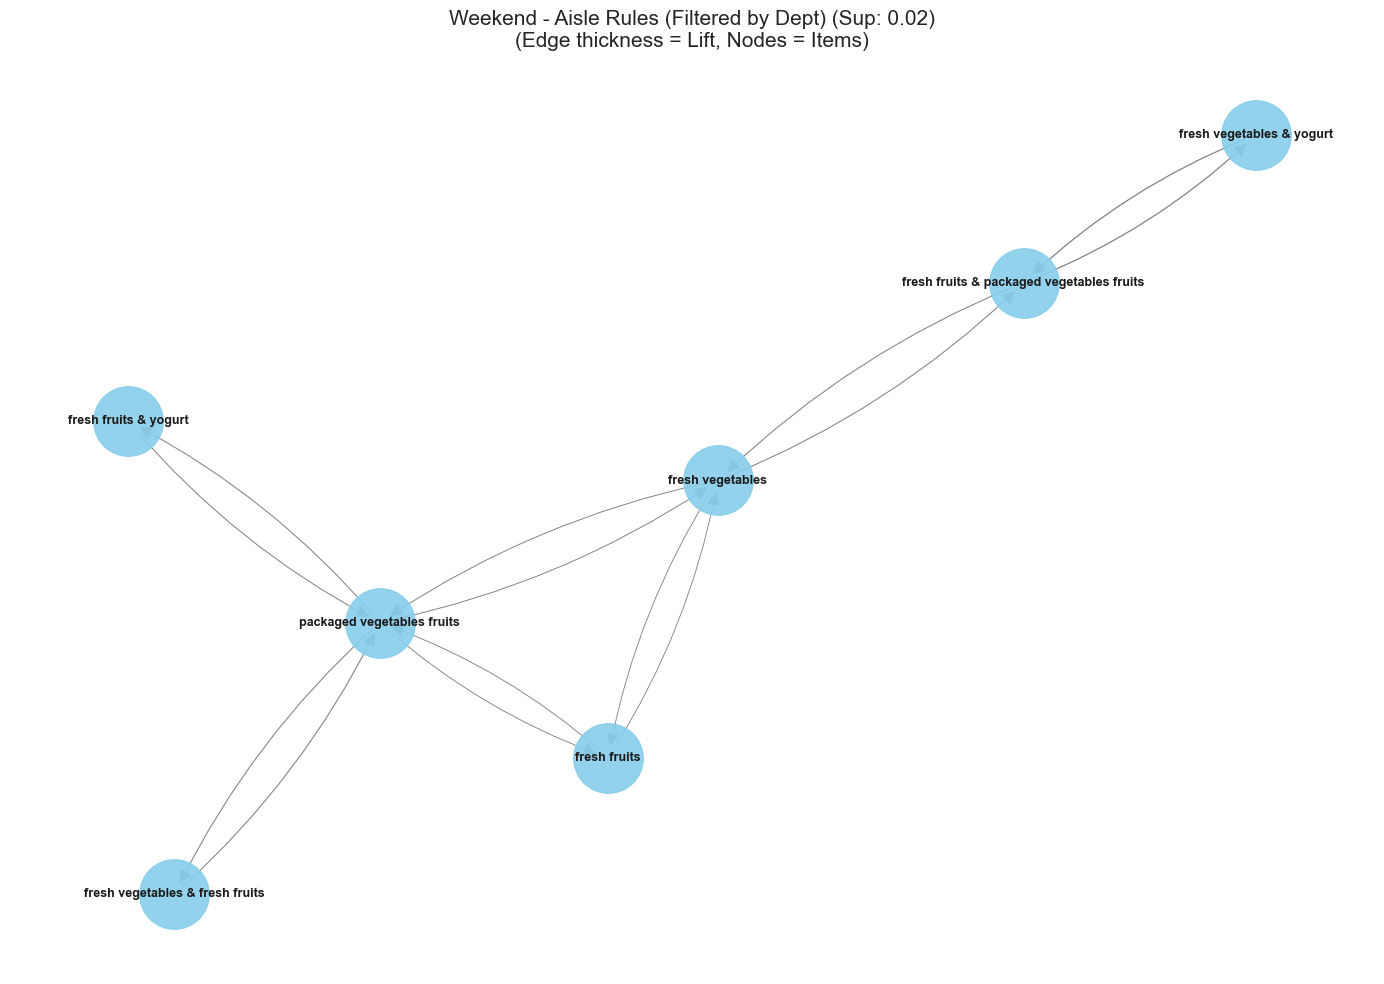

In [ ]:
### Redundancy Filtering Across Concept Hierarchies

scenarios = [
    ('Weekend', 0.01, 'prod_vs_aisle', 'Product Rules (Filtered by Aisle)'),
    ('Weekday', 0.01, 'prod_vs_aisle', 'Product Rules (Filtered by Aisle)'),
    ('Weekend', 0.02, 'aisle_vs_dept', 'Aisle Rules (Filtered by Dept)')
]

mapping_data = df_merged[['product_name', 'aisle', 'department']].drop_duplicates()
prod_to_aisle_map = mapping_data.set_index('product_name')['aisle'].to_dict()
aisle_to_dept_map = mapping_data[['aisle', 'department']].drop_duplicates().set_index('aisle')['department'].to_dict()
def get_rule_set(rules_df):
    if rules_df.empty: return set()
    return set(
        (tuple(sorted(list(row['antecedents']))), tuple(sorted(list(row['consequents']))))
        for _, row in rules_df.iterrows()
    )

filtered_results = {}
dimensions = benchmark_df['Dimension'].unique()
supports = benchmark_df['Min_Support'].unique()

for dim in dimensions:
    for sup in supports:
        rules_dept = all_rules.get((dim, 'department', sup), pd.DataFrame())
        rules_aisle = all_rules.get((dim, 'aisle', sup), pd.DataFrame())
        rules_prod = all_rules.get((dim, 'product_name', sup), pd.DataFrame())
        
        if not rules_aisle.empty and not rules_dept.empty:
            dept_rules_set = get_rule_set(rules_dept)
            interesting_aisle = filter_hierarchical_redundancy(rules_aisle, dept_rules_set, aisle_to_dept_map)
            filtered_results[(dim, sup, 'aisle_vs_dept')] = interesting_aisle
        else:
            filtered_results[(dim, sup, 'aisle_vs_dept')] = rules_aisle

        if not rules_prod.empty and not rules_aisle.empty:
            aisle_rules_set = get_rule_set(rules_aisle)
            interesting_prod = filter_hierarchical_redundancy(rules_prod, aisle_rules_set, prod_to_aisle_map)
            filtered_results[(dim, sup, 'prod_vs_aisle')] = interesting_prod
        else:
            filtered_results[(dim, sup, 'prod_vs_aisle')] = rules_prod

for dim, sup, r_type, title_suffix in scenarios:
    key = (dim, sup, r_type)
    if key in filtered_results:
        rules_to_plot = filtered_results[key]
        robust_rules = rules_to_plot[(rules_to_plot['kulczynski'] > 0.4) & (rules_to_plot['ir'] < 0.4)]
        full_title = f"{dim} - {title_suffix} (Sup: {sup})"
        plot_rules_network(robust_rules, title=full_title, num_rules=20)